In [8]:
import torch


def apply_masks(x, masks, concat=True):
    """
    :param x: tensor of shape [B (batch-size), N (num-patches), D (feature-dim)]
    :param masks: list of tensors of shape [B, K] containing indices of K patches in [N] to keep
    """
    all_x = []
    for m in masks:
        mask_keep = m.unsqueeze(-1).repeat(1, 1, x.size(-1))
        all_x += [torch.gather(x, dim=1, index=mask_keep)]
    if not concat:
        return all_x

    return torch.cat(all_x, dim=0)

In [9]:
def get_complement_masks(masks, n):
    """
    masks = [b, k] contains k patch indices in [0, n)
    Returns complement = [b, n-k] containing the remaining indices
    """
    b, k = masks.shape
    device = masks.device

    # Start with all indices marked as "keep" (True)
    keep = torch.ones(b, n, dtype=torch.bool, device=device)
    # Mark the masked indices as False (these are the ones we want to remove)
    keep.scatter_(1, masks, False)

    # The complement indices are those still marked True
    complement = torch.arange(n, device=device).unsqueeze(0).expand(b, -1)
    complement_indices = complement[keep].view(b, n - k)

    return complement_indices

In [10]:
import torch

x = torch.arange(1, 28).reshape(3, 3, 3)

print(x)

tensor([[[ 1,  2,  3],
         [ 4,  5,  6],
         [ 7,  8,  9]],

        [[10, 11, 12],
         [13, 14, 15],
         [16, 17, 18]],

        [[19, 20, 21],
         [22, 23, 24],
         [25, 26, 27]]])


In [11]:
y = torch.tensor([
    [0,1], [0,2], [1,0]
])
y.shape

torch.Size([3, 2])

In [12]:
y = [y]

In [13]:
y

[tensor([[0, 1],
         [0, 2],
         [1, 0]])]

In [14]:
z = torch.tensor([
    [2],[1],[2]
])

In [15]:
masked = apply_masks(x, y)

In [16]:
masked

tensor([[[ 1,  2,  3],
         [ 4,  5,  6]],

        [[10, 11, 12],
         [16, 17, 18]],

        [[22, 23, 24],
         [19, 20, 21]]])

In [19]:
complement = get_complement_masks(y[0],3)
complement

tensor([[2],
        [1],
        [2]])

In [20]:
masked_complement = apply_masks(x, [complement])
masked_complement

tensor([[[ 7,  8,  9]],

        [[13, 14, 15]],

        [[25, 26, 27]]])

In [42]:
y = torch.cat(y, dim=0)
y

tensor([[0, 1],
        [0, 2],
        [1, 0]])

In [43]:
y.shape

torch.Size([3, 2])

In [2]:
from PIL import Image

image = Image.open("image.png")

print(image.size)  # (width, height)

image.show()

(1455, 663)


In [7]:
from PIL import Image
import numpy as np
import torch


def image_to_tensor(image_path):
    """
    PIL Image -> Tensor [C, H, W]
    Range: [0, 1]
    """
    image = Image.open(image_path).convert("RGB")

    tensor = torch.tensor(
        np.array(image),
        dtype=torch.float32
    ).permute(2, 0, 1) / 255.0

    return tensor


def tensor_to_image(tensor):
    """
    Tensor [C, H, W] -> PIL Image
    Assumes tensor values are in [0,1]
    """

    tensor = tensor.detach().cpu()

    image = (
        tensor.permute(1, 2, 0)
        .numpy() * 255
    ).astype(np.uint8)

    return Image.fromarray(image)

In [11]:
image_tensor = image_to_tensor("image.png")

In [17]:
image_tensor.shape

torch.Size([3, 663, 1455])

In [14]:
import torch

B = 3
N = 663
K = 100   # number of masked patches

masks_tgt = []

for _ in range(B):
    idx = torch.randperm(N)[:K]
    masks_tgt.append(idx)

masks_tgt = torch.stack(masks_tgt)

print(masks_tgt)

tensor([[434, 245, 211, 383, 630,  76, 522, 606, 153, 659,  21, 286, 215, 234,
         309, 298,  59, 640, 570, 588, 634, 460,  26, 614, 456, 127, 417, 469,
         393, 579,   6, 568,  84, 380, 398, 191, 514, 394,  54, 262, 242, 483,
         305, 306, 100, 422, 432, 243, 470, 519, 649, 340, 494, 304, 128, 354,
          79, 412, 112, 113, 182, 490, 135, 315, 355, 609, 518, 455, 218, 281,
         365,  74, 604, 476, 226, 501, 442, 192,  53, 428, 176, 136, 444, 420,
          81, 642, 106, 129, 333, 504, 618, 146,  63,  65, 149, 312, 270, 554,
         399, 255],
        [367, 206,  90, 135, 535, 468, 438, 584,  89, 387, 460,  37, 569, 583,
         228, 286, 514, 350, 556, 647, 305, 587, 557, 227, 651, 258,  52, 608,
         565, 279,  21, 358, 318, 336, 562, 191, 157, 662, 503, 327, 344, 278,
         354, 248, 431, 499, 326, 393, 201,  57, 100, 144, 487,   0, 517, 567,
         102, 108, 493, 581, 139, 528, 247, 229, 455, 477, 652, 513, 578, 347,
         246, 541, 502, 544, 522

In [41]:
import torch
import numpy as np
from PIL import Image

# --- Your existing functions ---
def image_to_tensor(image_path):
    image = Image.open(image_path).convert("RGB")
    tensor = torch.tensor(np.array(image), dtype=torch.float32).permute(2, 0, 1) / 255.0
    return tensor

def tensor_to_image(tensor):
    tensor = tensor.detach().cpu()
    image = (tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    return Image.fromarray(image)
# -------------------------------

# 1. Load the image
image_tensor = image_to_tensor("image.png")  # Shape: [3, 663, 1455]

# 2. Define patch parameters
patch_size = 32
K = 250

H, W = image_tensor.shape[1], image_tensor.shape[2]
n_patches_h = H // patch_size
n_patches_w = W // patch_size
total_patches = n_patches_h * n_patches_w

# 3. Randomly select K patches to mask
masked_indices = torch.randperm(total_patches)[:K]

# 4. Create a mask tensor initialized to 1 (keeping all image info)
mask = torch.ones_like(image_tensor)

# 5. Set the selected 2D patches to 0 (removing the information)
for idx in masked_indices:
    # Calculate top-left corner of the patch
    row = (idx // n_patches_w) * patch_size
    col = (idx % n_patches_w) * patch_size
    
    # Set this patch region to 0 (black)
    mask[:, row:row+patch_size, col:col+patch_size] = 0.0

# 6. Apply the mask to the image
masked_image_tensor = image_tensor * mask

# 7. Convert the single masked tensor back to a PIL Image
final_image = tensor_to_image(masked_image_tensor)

# To view it in a Jupyter Notebook / script:
# display(final_image) 

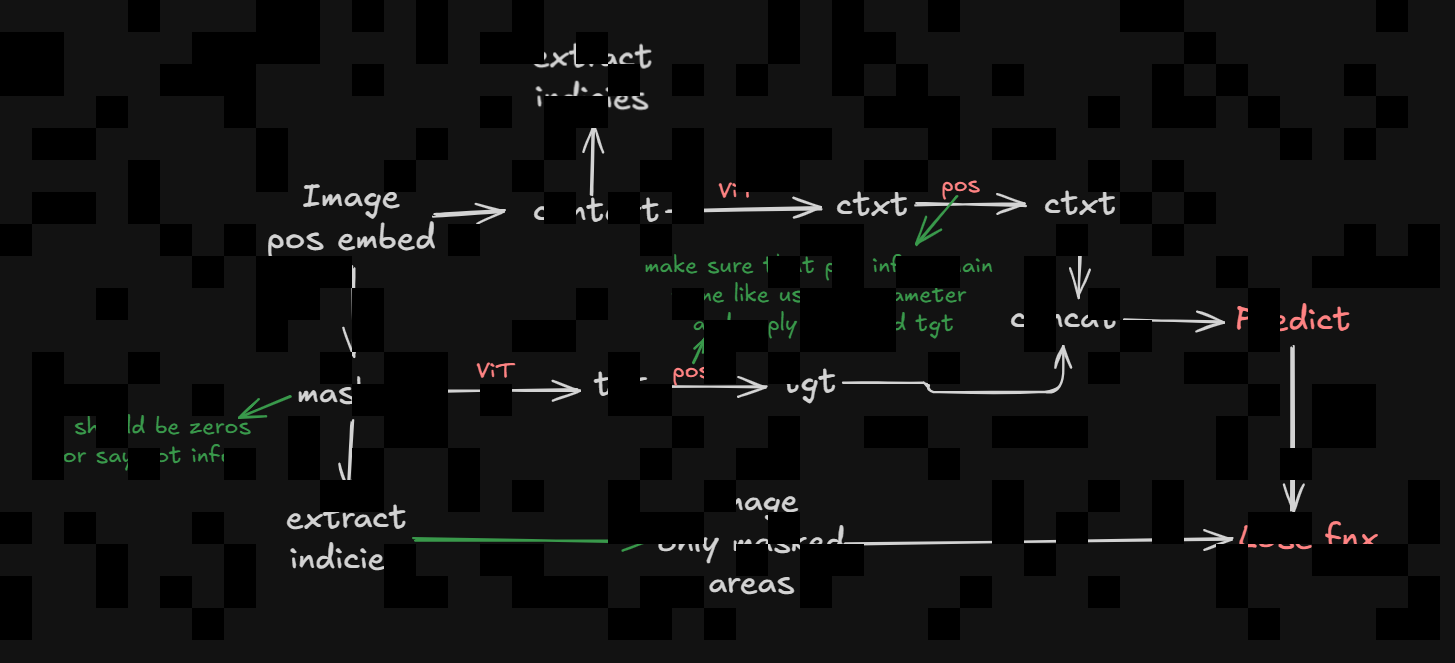

In [42]:
final_image